In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/processed/customer_features.csv')

print(df.describe())
print(f'\nChurn rate: {df.churned.mean():.1%}')

       recency_days     frequency      monetary  avg_order_value  \
count  55267.000000  55267.000000  55267.000000     55267.000000   
mean     155.452512      1.032298    162.267139       154.827290   
std      109.881189      0.201833    222.563684       213.059226   
min        0.000000      1.000000     10.070000         1.856818   
25%       63.000000      1.000000     62.510000        60.010000   
50%      133.000000      1.000000    106.170000       102.030000   
75%      238.000000      1.000000    179.600000       172.075000   
max      420.000000      9.000000  13664.080000     13664.080000   

       avg_review_score  min_review_score  review_count  num_unique_products  \
count      55267.000000      55267.000000  55267.000000         55267.000000   
mean           4.122326          4.111767      1.032461             1.068124   
std            1.287218          1.299089      0.271633             0.312658   
min            1.000000          1.000000      0.000000            

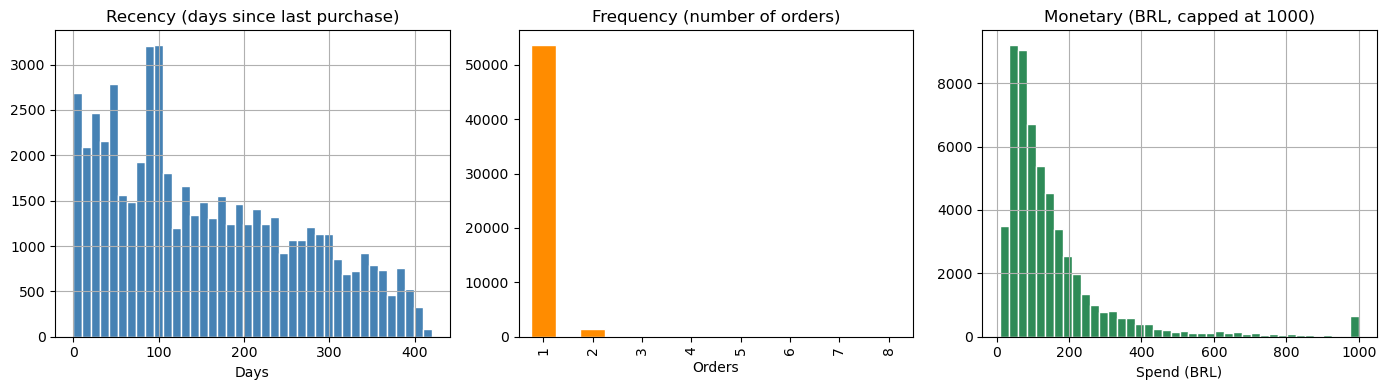

In [4]:
  fig, axes = plt.subplots(1, 3, figsize=(14, 4))
  
  df['recency_days'].hist(ax=axes[0], bins=40, color='steelblue', edgecolor='white')
  axes[0].set_title('Recency (days since last purchase)')
  axes[0].set_xlabel('Days')
  
  df['frequency'].value_counts().sort_index().head(8).plot(
      kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
  axes[1].set_title('Frequency (number of orders)')
  axes[1].set_xlabel('Orders')
  
  df['monetary'].clip(upper=1000).hist(ax=axes[2], bins=40, color='seagreen', edgecolor='white')
  axes[2].set_title('Monetary (BRL, capped at 1000)')
  axes[2].set_xlabel('Spend (BRL)')
  
  plt.tight_layout()
  plt.savefig('../figures/rfm_distribution.png')
  plt.show()

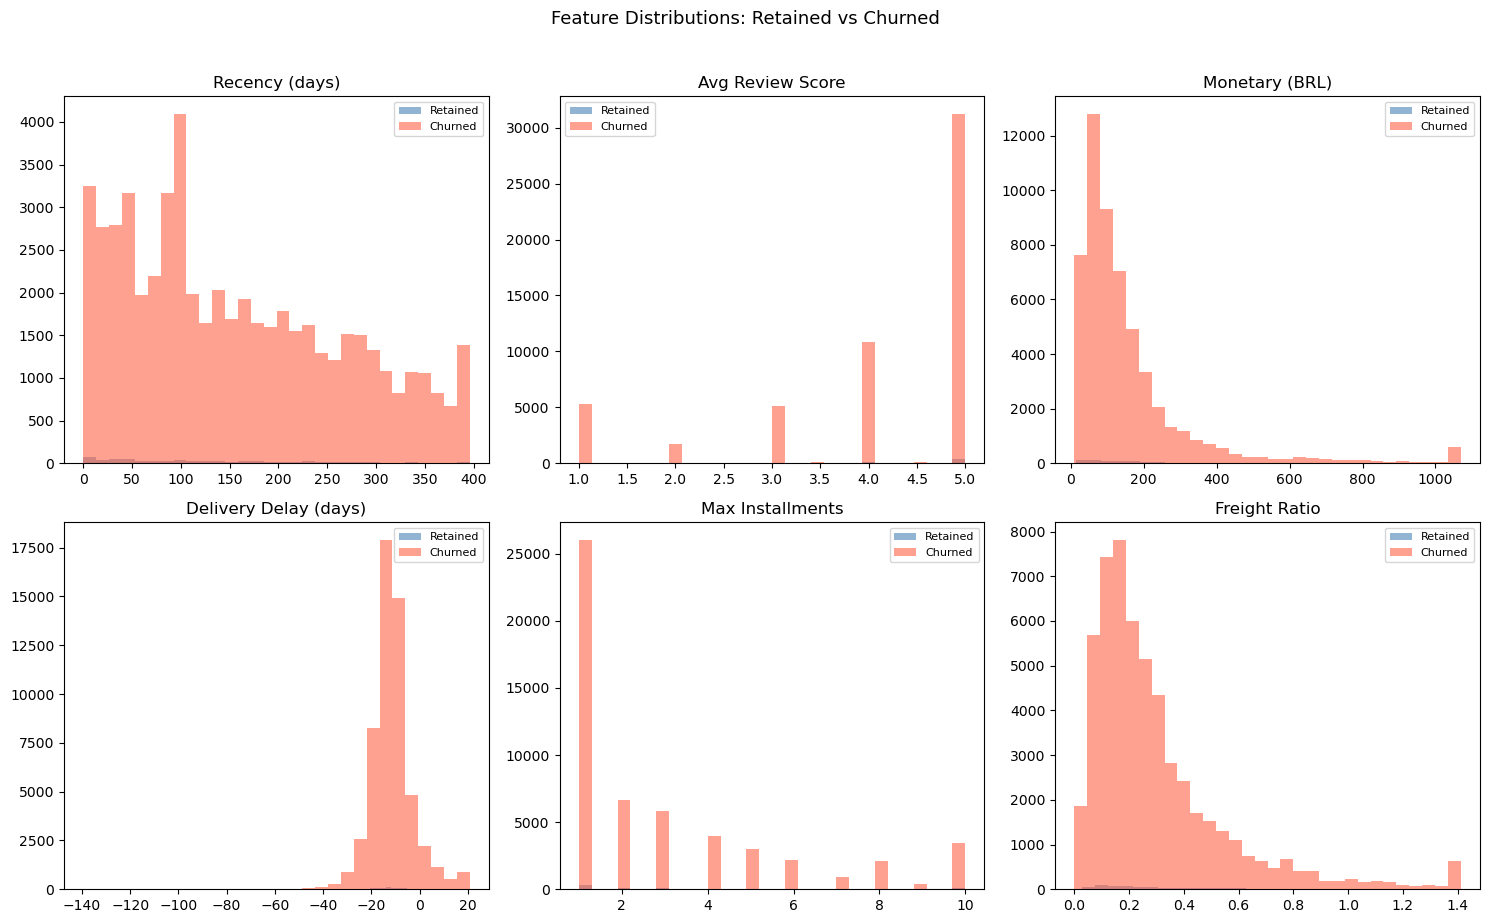

In [5]:
  fig, axes = plt.subplots(2, 3, figsize=(15, 9))
  
  features_to_plot = [
      ('recency_days',             'Recency (days)'),
      ('avg_review_score',         'Avg Review Score'),
      ('monetary',                 'Monetary (BRL)'),
      ('avg_delivery_delay_days',  'Delivery Delay (days)'),
      ('max_installments',         'Max Installments'),
      ('avg_freight_ratio',        'Freight Ratio'),
  ]   
  
  for ax, (feat, title) in zip(axes.flatten(), features_to_plot):
      retained = df[df['churned'] == 0][feat].clip(
          upper=df[feat].quantile(0.99))
      churned  = df[df['churned'] == 1][feat].clip(
          upper=df[feat].quantile(0.99))
      ax.hist(retained, bins=30, alpha=0.6, color='steelblue',  label='Retained')
      ax.hist(churned,  bins=30, alpha=0.6, color='tomato',     label='Churned')
      ax.set_title(title)
      ax.legend(fontsize=8)
      
  plt.suptitle('Feature Distributions: Retained vs Churned', y=1.02, fontsize=13)
  plt.tight_layout()
  plt.savefig('../figures/feature_vs_churn.png', bbox_inches='tight')
  plt.show()



In [6]:
  from sklearn.preprocessing import StandardScaler
  from sklearn.cluster import KMeans
  
  # 标准化 RFM
  scaler = StandardScaler()
  rfm_scaled = scaler.fit_transform(df[['recency_days', 'frequency', 'monetary']])
  
  # K-Means 分4群
  km = KMeans(n_clusters=4, random_state=42, n_init=10)
  df['segment'] = km.fit_predict(rfm_scaled) 
  
  # 各群画像
  seg_profile = df.groupby('segment').agg(
      customers   = ('customer_unique_id', 'count'),
      recency     = ('recency_days',        'mean'),
      frequency   = ('frequency',           'mean'),
      monetary    = ('monetary',            'mean'),
      churn_rate  = ('churned',             'mean')
  ).round(2).sort_values('churn_rate')      
  
  print(seg_profile)

         customers  recency  frequency  monetary  churn_rate
segment                                                     
3             1603   137.87       2.11    287.42        0.96
0            31746    79.58       1.00    130.26        0.99
1            20261   275.09       1.00    129.43        0.99
2             1657   163.24       1.01   1055.88        0.99


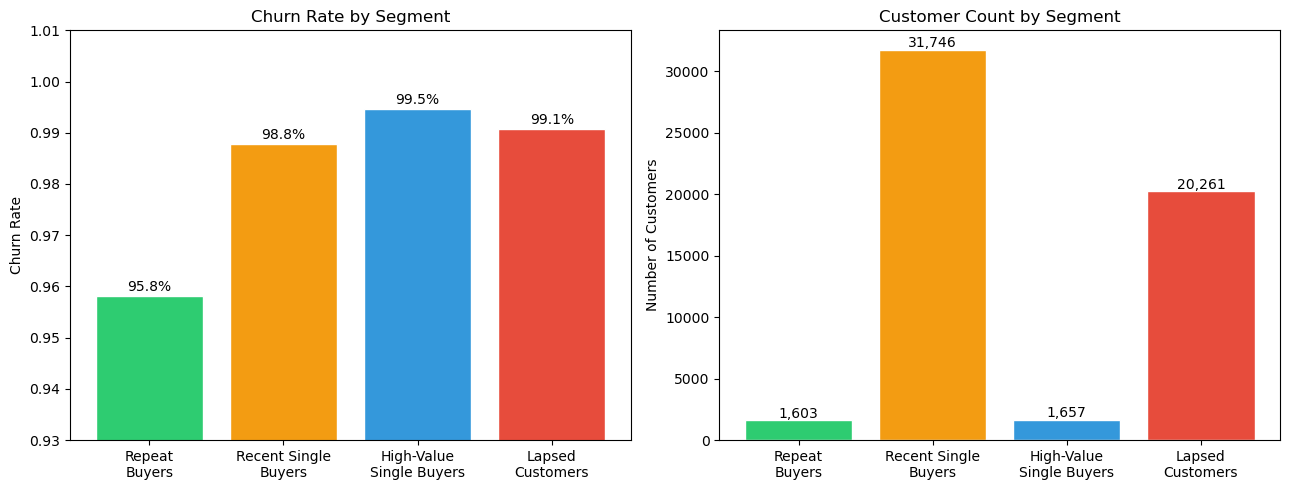

In [7]:
  seg_label_map = {
      3: 'Repeat\nBuyers',
      0: 'Recent Single\nBuyers',
      2: 'High-Value\nSingle Buyers',
      1: 'Lapsed\nCustomers'
  }
  df['segment_label'] = df['segment'].map(seg_label_map)

  # 同时展示 churn rate 和客户数量
  fig, axes = plt.subplots(1, 2, figsize=(13, 5))

  # 左图：各群 Churn Rate
  churn_by_seg = df.groupby('segment_label')['churned'].mean()
  order = ['Repeat\nBuyers', 'Recent Single\nBuyers', 'High-Value\nSingle Buyers', 'Lapsed\nCustomers']
  colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']
  bars = axes[0].bar(order, [churn_by_seg[s] for s in order], color=colors, edgecolor='white')
  axes[0].set_title('Churn Rate by Segment', fontsize=12)
  axes[0].set_ylabel('Churn Rate')
  axes[0].set_ylim(0.93, 1.01)  
  for bar, val in zip(bars, [churn_by_seg[s] for s in order]):
      axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                   f'{val:.1%}', ha='center', fontsize=10)
  
  # 右图：各群客户数量
  size_by_seg = df.groupby('segment_label')['customer_unique_id'].count()
  axes[1].bar(order, [size_by_seg[s] for s in order], color=colors, edgecolor='white')
  axes[1].set_title('Customer Count by Segment', fontsize=12)
  axes[1].set_ylabel('Number of Customers')
  for i, val in enumerate([size_by_seg[s] for s in order]):
      axes[1].text(i, val + 200, f'{val:,}', ha='center', fontsize=10)

  plt.tight_layout()  
  plt.savefig('../figures/churn_by_segment.png')
  plt.show()